In [7]:
%load_ext autoreload
%autoreload 2

save_plot = False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sys
sys.path.append('..')
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *
import seaborn as sns

# Tell Matplotlib to export text as text, not paths (editable in Illustrator)
plt.rcParams['svg.fonttype'] = 'none'

In [9]:
# gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_large_detail.parquet")

In [10]:
# gene_perf

In [11]:
# new_metrics = compute_new_corr_metrics(
#     gene_perf,
#     deg=[1000, 2000, 5000],
#     sign_tau=0.0,
#     updown_tau=0.0,
#     de_frac=0.1,
#     topk_values=(100,),
    
# )
# new_metrics.to_parquet("new_metrics.parquet")

In [12]:
# new_metrics = pd.read_parquet("new_metrics.parquet")

new_metrics =pd.read_parquet("new_metrics_large_all.parquet")
new_metrics['DataSet'] = new_metrics['DataSet'].replace({
    'HCT_large': 'HCT116',
    'HEK_large': 'HEK293T',
    'K562_large': 'K562',
    'hepg2_large': 'HepG2',
    'jurkat_large': 'Jurkat',
    'rpe1_large': 'RPE1',
})

# Keep only perturbations present in every (method, DataSet) combination
combos = new_metrics.groupby('perturb')[['method', 'DataSet']].apply(
    lambda g: (g['method'].nunique(), g['DataSet'].nunique())
)
n_methods = new_metrics['method'].nunique()
n_datasets = new_metrics['DataSet'].nunique()

common_perts = new_metrics.groupby('perturb').filter(
    lambda g: g['method'].nunique() == n_methods and g['DataSet'].nunique() == n_datasets
)['perturb'].unique()

new_metrics1 = new_metrics[new_metrics['perturb'].isin(common_perts)]
expected = 5 * 6 * 3 * 1 * 15  # methods × datasets × DEGs × splits × metrics = 1350
full_perts = new_metrics1.groupby('perturb').filter(lambda g: len(g) == expected)['perturb'].unique()
new_metrics = new_metrics[new_metrics['perturb'].isin(full_perts)]

# keep_metrics = [
#     'pearson_distance_raw', 'spearman_distance_raw',
#     'pearson_distance_delta', 'spearman_distance_delta',
#     'mean_absolute_error_delta', 'mean_squared_error_delta',
#     'root_mean_squared_error_delta','sign_error_delta', 'topk_jaccard_distance_delta_k100'
# ]

# new_metrics_sub = new_metrics[new_metrics['metric'].isin(keep_metrics)]

# expected = (new_metrics_sub['method'].nunique()
#             * new_metrics_sub['DataSet'].nunique()
#             * new_metrics_sub['DEG'].nunique()
#             * len(keep_metrics))

# full_perts = new_metrics_sub.groupby('perturb').filter(
#     lambda g: len(g) == expected
# )['perturb'].unique()

# new_metrics1 = new_metrics_sub[new_metrics_sub['perturb'].isin(full_perts)]
# print(f"Kept {len(full_perts)} / {new_metrics_sub['perturb'].nunique()} perturbations, "
#       f"expected {expected} rows each")

In [13]:
# PSI_rankings = pd.read_parquet("PSI_rankings.parquet")
PSI_rankings = pd.read_parquet("PSI_rankings_large.parquet")
PSI_rankings = PSI_rankings[PSI_rankings.perturbation.isin(new_metrics.perturb.unique().tolist())]
sorted_psi = PSI_rankings.sort_values('global_PSI')

n = len(sorted_psi)
q25 = n // 4
q50 = n // 2
q75 = 3 * n // 4

bottom_quarter = sorted_psi.iloc[:q25]['perturbation'].tolist()       # bottom 25% (sledgehammers)
third_quarter = sorted_psi.iloc[q25:q50]['perturbation'].tolist()     # 25-50%
second_quarter = sorted_psi.iloc[q50:q75]['perturbation'].tolist()    # 50-75%
top_quarter = sorted_psi.iloc[q75:]['perturbation'].tolist()          # top 25% (scalpels)


In [14]:
from scipy.stats import spearmanr
import itertools

METHOD_ORDER = ['trainMean', 'GenePert', 'scouter', 'scGPT', 'GEARS', 'CPA']
HEATMAP_METHODS = ['trainMean', 'scGPT', 'GEARS', 'CPA']

PALETTE = {
    'trainMean': '#386cb0',
    'GenePert': '#386cb0',
    'scouter': '#7fc97f',
    'scGPT': '#beaed4',
    'GEARS': '#fdc086',
    'CPA': '#ffff99',
}

quarter_names = ['Scalpels', '2nd quartile', '3rd quartile', 'Sledgehammers']
quarter_names_bar = ['Scalpels', '2nd\nquartile', '3rd\nquartile', 'Sledgehammers']
quarter_lists = [top_quarter, second_quarter, third_quarter, bottom_quarter]

# Compute data for all DEGs
all_best_dfs = {}
all_cdf_data = {}

for deg in [1000, 2000, 5000]:
    best_counts_all = []
    cdf_data = {}

    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'spearman_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]
               
        print(f"DEG={deg}, {qname}: {sub['perturb'].nunique()} perturbations")


        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')
        methods = [m for m in HEATMAP_METHODS if m in pivot.columns]
        pivot = pivot[methods]

        pivot['oracle_best'] = pivot[methods].min(axis=1)
        pivot['best_method'] = pivot[methods].idxmin(axis=1)

        counts = pivot['best_method'].value_counts()
        for m in methods:
            best_counts_all.append({
                'quarter': qname, 'method': m,
                'pct': counts.get(m, 0) / len(pivot) * 100
            })

        if qname in ['Scalpels', 'Sledgehammers']:
            for m in ['trainMean', 'oracle_best']:
                if m in pivot.columns:
                    vals = np.sort(pivot[m].dropna().values)
                    cdf_data[(qname, m)] = vals

    all_best_dfs[deg] = pd.DataFrame(best_counts_all)
    all_cdf_data[deg] = cdf_data

print("Data computed for all DEGs.")

DEG=1000, Scalpels: 478 perturbations
DEG=1000, 2nd quartile: 478 perturbations
DEG=1000, 3rd quartile: 478 perturbations
DEG=1000, Sledgehammers: 478 perturbations
DEG=2000, Scalpels: 478 perturbations
DEG=2000, 2nd quartile: 478 perturbations
DEG=2000, 3rd quartile: 478 perturbations
DEG=2000, Sledgehammers: 478 perturbations
DEG=5000, Scalpels: 478 perturbations
DEG=5000, 2nd quartile: 478 perturbations
DEG=5000, 3rd quartile: 478 perturbations
DEG=5000, Sledgehammers: 478 perturbations
Data computed for all DEGs.


DEG=1000: unknown perturbations


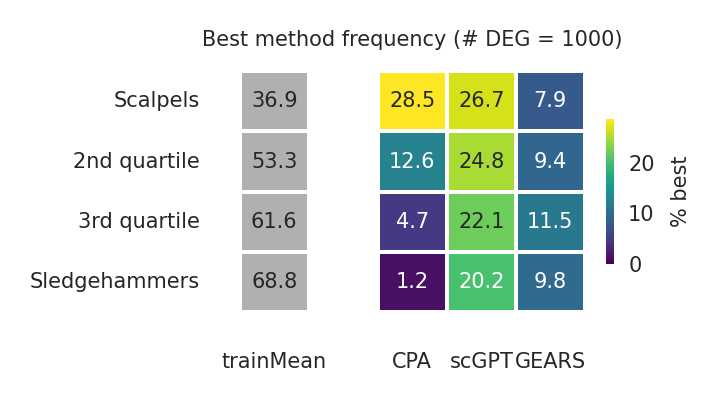

DEG=2000: unknown perturbations


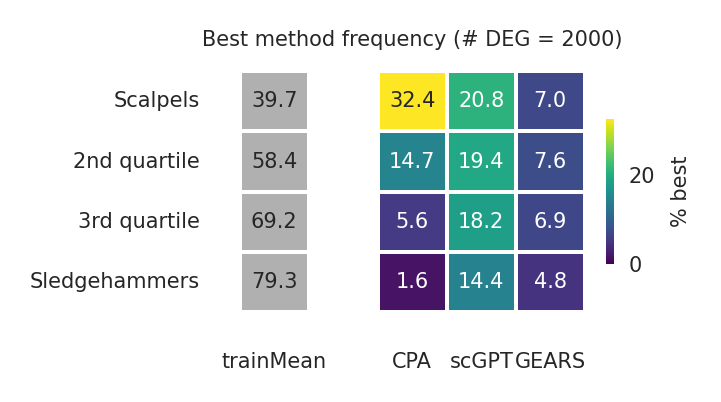

DEG=5000: unknown perturbations


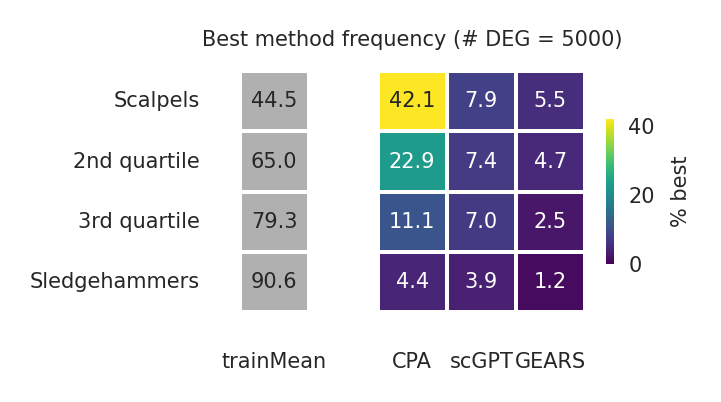

In [15]:
# =========================================================
# Heatmap: % best method per PSI quartile (Spearman)
# =========================================================
sns.set_theme(style="white")

HEATMAP_METHODS_4 = ['trainMean', 'CPA', 'scGPT', 'GEARS', 'GenePert']

from matplotlib.colors import ListedColormap

for deg in [1000, 2000, 5000]:
    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)

    best_df = all_best_dfs[deg]
    best_df_filt = best_df[best_df['method'].isin(HEATMAP_METHODS_4)]
    print(f"DEG={deg}: {best_df_filt['perturb'].nunique() if 'perturb' in best_df_filt.columns else 'unknown'} perturbations")

    best_pivot = best_df_filt.pivot(index='quarter', columns='method', values='pct')
    best_pivot = best_pivot.reindex(quarter_names)
    best_pivot = best_pivot[[m for m in HEATMAP_METHODS_4 if m in best_pivot.columns]]

    # Insert blank separator column
    best_pivot.insert(1, '', np.nan)

    # Masks
    is_trainmean = np.tile([c == 'trainMean' for c in best_pivot.columns], (len(best_pivot), 1))
    is_sep = np.tile([c == '' for c in best_pivot.columns], (len(best_pivot), 1))
    is_other = ~is_trainmean & ~is_sep

    # Flat grey for trainMean
    flat_grey = ListedColormap(['#b0b0b0'])
    sns.heatmap(best_pivot, annot=True, fmt='.1f', cmap=flat_grey, ax=ax,
                mask=~is_trainmean, linewidths=0.5,
                cbar=False, annot_kws={'fontsize': 5})

    # Viridis for others
    other_vals = best_pivot.loc[:, [c for c in best_pivot.columns if c not in ['trainMean', '']]].values
    sns.heatmap(best_pivot, annot=True, fmt='.1f', cmap='viridis', ax=ax,
                mask=~is_other, linewidths=0.5,
                vmin=0, vmax=np.nanmax(other_vals),
                cbar_kws={'shrink': 0.6, 'label': '% best'},
                annot_kws={'fontsize': 5})

    # White out separator column
    for i in range(len(best_pivot)):
        ax.add_patch(plt.Rectangle((1, i), 1, 1, fill=True, color='white', lw=0))

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'Best method frequency (# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5)
    ax.tick_params(axis='y', rotation=0, labelsize=5)
    cbar = ax.collections[1].colorbar
    cbar.ax.tick_params(labelsize=5, length=0)
    cbar.set_label('% best', fontsize=5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_spearman_heatmap_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_spearman_heatmap_DEG{deg}.svg', bbox_inches='tight', dpi=300)
    plt.show()


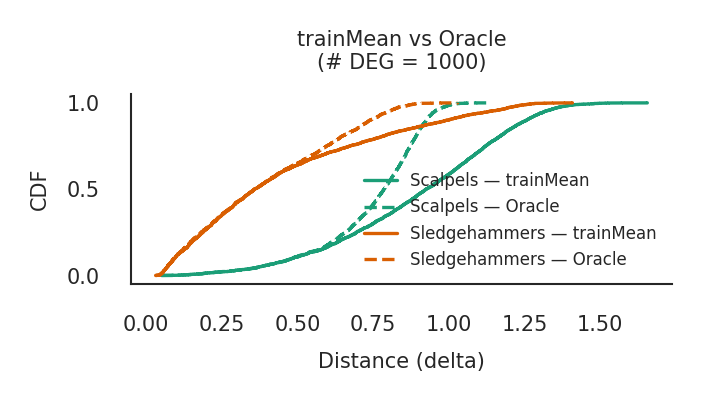

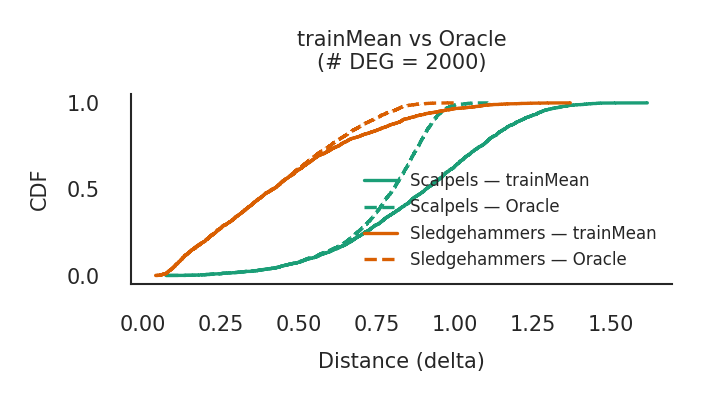

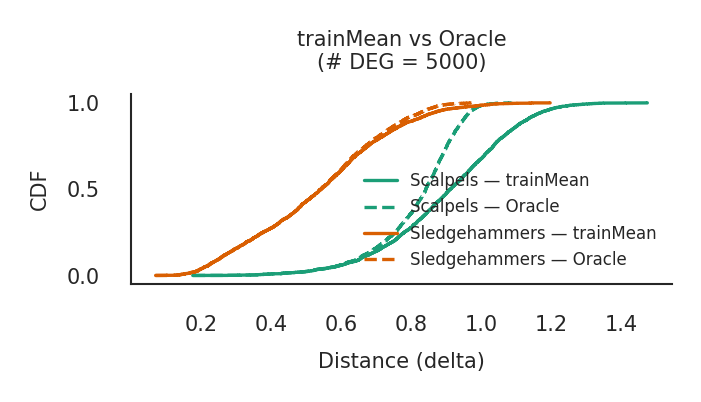

In [16]:
# =========================================================
# CDF: trainMean vs oracle for Scalpels & Sledgehammers (Spearman)
# =========================================================
sns.set_theme(style="white")

cdf_colors = {
    ('Scalpels', 'trainMean'): '#1b9e77',
    ('Scalpels', 'oracle_best'): '#1b9e77',
    ('Sledgehammers', 'trainMean'): '#d95f02',
    ('Sledgehammers', 'oracle_best'): '#d95f02',
}
cdf_styles = {'trainMean': '-', 'oracle_best': '--'}
cdf_labels = {'trainMean': 'trainMean', 'oracle_best': 'Oracle'}

for deg in [1000, 2000, 5000]:
    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    cdf_data = all_cdf_data[deg]

    for qname in ['Scalpels', 'Sledgehammers']:
        for m in ['trainMean', 'oracle_best']:
            if (qname, m) not in cdf_data:
                continue
            vals = cdf_data[(qname, m)]
            cdf_y = np.arange(1, len(vals) + 1) / len(vals)
            ax.step(vals, cdf_y, where='post',
                    color=cdf_colors[(qname, m)],
                    linestyle=cdf_styles[m],
                    linewidth=0.8,
                    label=f'{qname} — {cdf_labels[m]}')

    ax.set_xlabel('Distance (delta)', fontsize=5)
    ax.set_ylabel('CDF', fontsize=5)
    ax.set_title(f'trainMean vs Oracle\n(# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', labelsize=5, direction='out', length=4, width=0.8)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, loc='lower right', frameon=False)

    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_spearman_cdf_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_spearman_cdf_DEG{deg}.svg', bbox_inches='tight', dpi=300)
    plt.show()

In [20]:
from scipy.stats import ttest_rel, ks_2samp

deg = 2000
cdf_data = all_cdf_data[deg]

# Within-group: trainMean vs Oracle
for qname in ['Scalpels', 'Sledgehammers']:
    stat, pval = ttest_rel(cdf_data[(qname, 'trainMean')], cdf_data[(qname, 'oracle_best')])
    print(f"{qname}: trainMean vs Oracle, t={stat:.3f}, p={pval:.2e}")

# Between-group: Scalpels vs Sledgehammers
for m in ['trainMean', 'oracle_best']:
    stat, pval = ks_2samp(cdf_data[('Scalpels', m)], cdf_data[('Sledgehammers', m)])
    print(f"Scalpels vs Sledgehammers ({m}): KS={stat:.3f}, p={pval:.2e}")


Scalpels: trainMean vs Oracle, t=62.638, p=0.00e+00
Sledgehammers: trainMean vs Oracle, t=27.290, p=5.65e-146
Scalpels vs Sledgehammers (trainMean): KS=0.597, p=0.00e+00
Scalpels vs Sledgehammers (oracle_best): KS=0.620, p=0.00e+00


In [21]:
gap_scalpels = cdf_data[('Scalpels', 'trainMean')] - cdf_data[('Scalpels', 'oracle_best')]
gap_sledge = cdf_data[('Sledgehammers', 'trainMean')] - cdf_data[('Sledgehammers', 'oracle_best')]

print(f"Mean gap Scalpels: {gap_scalpels.mean():.4f}")
print(f"Mean gap Sledgehammers: {gap_sledge.mean():.4f}")

# Mann-Whitney U since groups are different perturbations (unpaired)
from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(gap_scalpels, gap_sledge, alternative='greater')
print(f"Mann-Whitney U (Scalpels gap > Sledgehammers gap): U={stat:.0f}, p={pval:.2e}")


Mean gap Scalpels: 0.1235
Mean gap Sledgehammers: 0.0287
Mann-Whitney U (Scalpels gap > Sledgehammers gap): U=6824257, p=0.00e+00


In [41]:
# =========================================================
# Pearson: compute win % and CDF data
# =========================================================
all_best_dfs_pearson = {}
all_cdf_data_pearson = {}

for deg in [1000, 2000, 5000]:
    best_counts_all = []
    cdf_data = {}

    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'pearson_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]

        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')
        methods = [m for m in HEATMAP_METHODS if m in pivot.columns]
        pivot = pivot[methods]

        pivot['oracle_best'] = pivot[methods].min(axis=1)
        pivot['best_method'] = pivot[methods].idxmin(axis=1)

        counts = pivot['best_method'].value_counts()
        for m in methods:
            best_counts_all.append({
                'quarter': qname, 'method': m,
                'pct': counts.get(m, 0) / len(pivot) * 100
            })

        if qname in ['Scalpels', 'Sledgehammers']:
            for m in ['trainMean', 'oracle_best']:
                if m in pivot.columns:
                    vals = np.sort(pivot[m].dropna().values)
                    cdf_data[(qname, m)] = vals

    all_best_dfs_pearson[deg] = pd.DataFrame(best_counts_all)
    all_cdf_data_pearson[deg] = cdf_data

print("Pearson data computed for all DEGs.")

Pearson data computed for all DEGs.


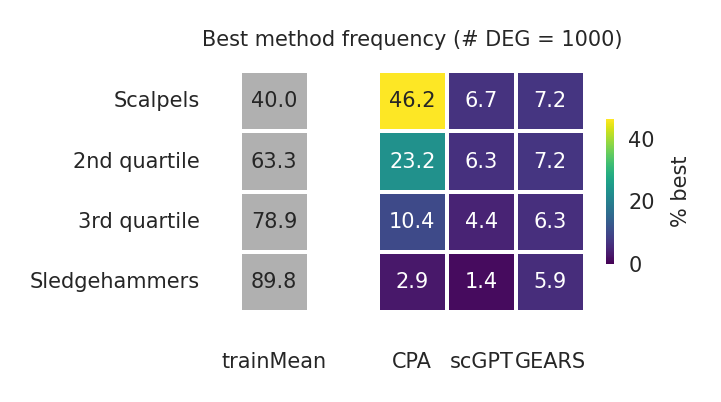

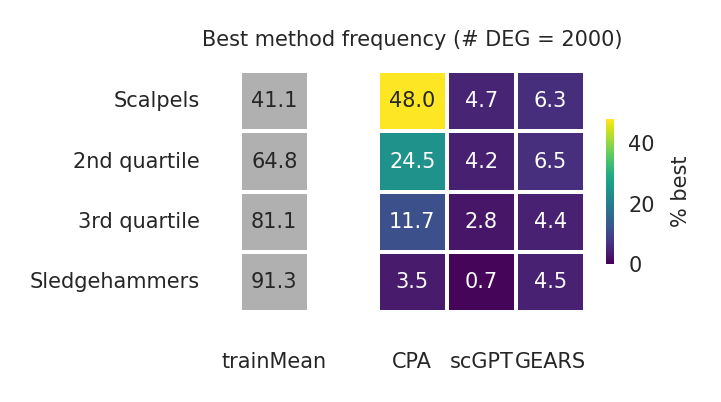

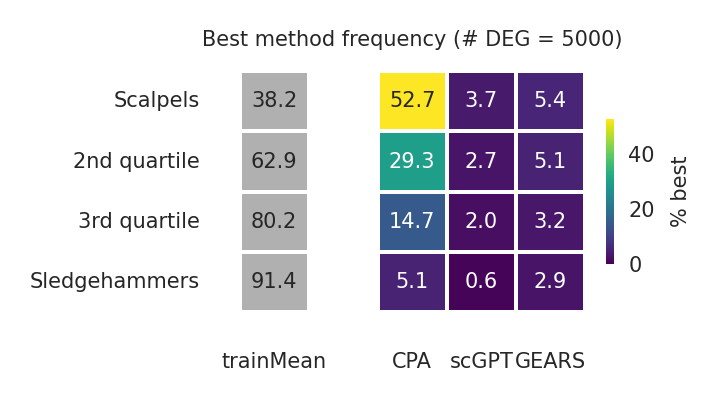

In [42]:
# =========================================================
# Pearson: Heatmap — win frequency per PSI quartile
# =========================================================
sns.set_theme(style="white")

HEATMAP_METHODS_4 = ['trainMean', 'CPA', 'scGPT', 'GEARS']

from matplotlib.colors import ListedColormap

for deg in [1000, 2000, 5000]:
    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)

    best_df = all_best_dfs_pearson[deg]
    best_df_filt = best_df[best_df['method'].isin(HEATMAP_METHODS_4)]
    best_pivot = best_df_filt.pivot(index='quarter', columns='method', values='pct')
    best_pivot = best_pivot.reindex(quarter_names)
    best_pivot = best_pivot[[m for m in HEATMAP_METHODS_4 if m in best_pivot.columns]]

    # Insert blank separator column
    best_pivot.insert(1, '', np.nan)

    # Masks
    is_trainmean = np.tile([c == 'trainMean' for c in best_pivot.columns], (len(best_pivot), 1))
    is_sep = np.tile([c == '' for c in best_pivot.columns], (len(best_pivot), 1))
    is_other = ~is_trainmean & ~is_sep

    # Flat grey for trainMean
    flat_grey = ListedColormap(['#b0b0b0'])
    sns.heatmap(best_pivot, annot=True, fmt='.1f', cmap=flat_grey, ax=ax,
                mask=~is_trainmean, linewidths=0.5,
                cbar=False, annot_kws={'fontsize': 5})

    # Viridis for others
    other_vals = best_pivot.loc[:, [c for c in best_pivot.columns if c not in ['trainMean', '']]].values
    sns.heatmap(best_pivot, annot=True, fmt='.1f', cmap='viridis', ax=ax,
                mask=~is_other, linewidths=0.5,
                vmin=0, vmax=np.nanmax(other_vals),
                cbar_kws={'shrink': 0.6, 'label': '% best'},
                annot_kws={'fontsize': 5})

    # White out separator column
    for i in range(len(best_pivot)):
        ax.add_patch(plt.Rectangle((1, i), 1, 1, fill=True, color='white', lw=0))

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'Best method frequency (# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5)
    ax.tick_params(axis='y', rotation=0, labelsize=5)
    cbar = ax.collections[1].colorbar
    cbar.ax.tick_params(labelsize=5, length=0)
    cbar.set_label('% best', fontsize=5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_pearson_heatmap_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_pearson_heatmap_DEG{deg}.svg', bbox_inches='tight')
    plt.show()


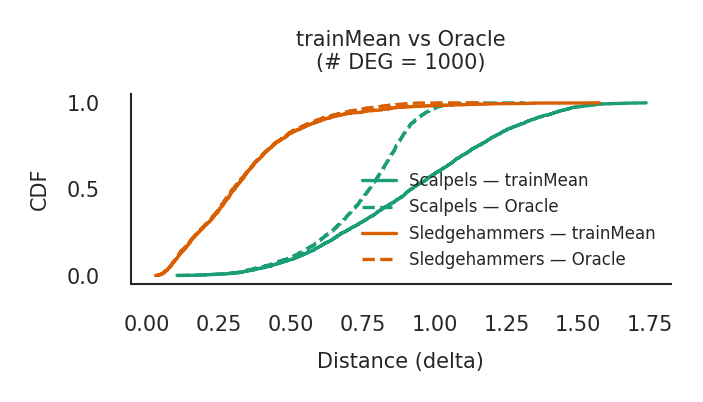

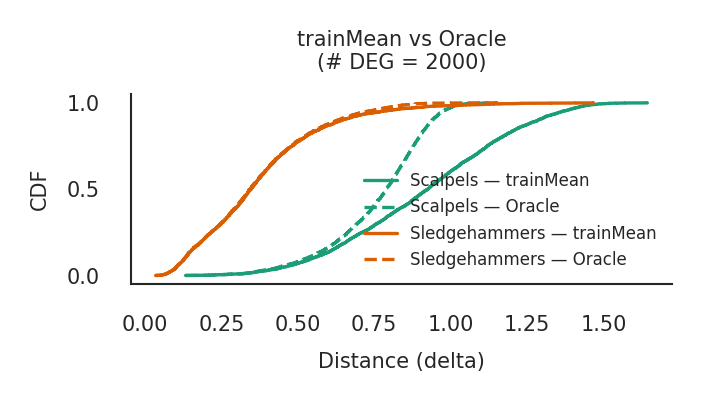

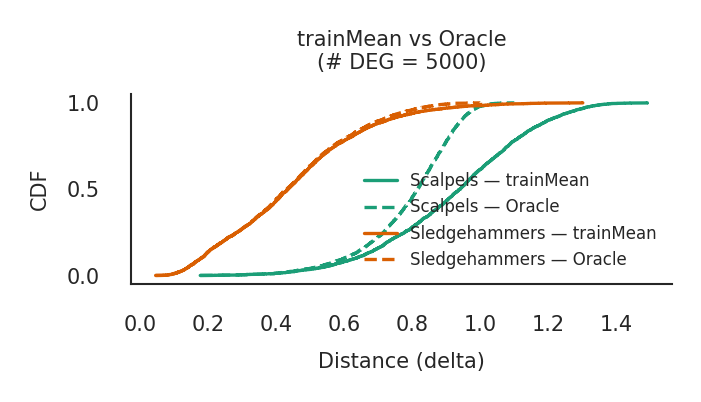

In [43]:
# =========================================================
# Pearson: CDF — trainMean vs oracle for Scalpels & Sledgehammers
# =========================================================
sns.set_theme(style="white")

cdf_colors = {
    ('Scalpels', 'trainMean'): '#1b9e77',
    ('Scalpels', 'oracle_best'): '#1b9e77',
    ('Sledgehammers', 'trainMean'): '#d95f02',
    ('Sledgehammers', 'oracle_best'): '#d95f02',
}
cdf_styles = {'trainMean': '-', 'oracle_best': '--'}
cdf_labels = {'trainMean': 'trainMean', 'oracle_best': 'Oracle'}

for deg in [1000, 2000, 5000]:
    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    cdf_data = all_cdf_data_pearson[deg]

    for qname in ['Scalpels', 'Sledgehammers']:
        for m in ['trainMean', 'oracle_best']:
            if (qname, m) not in cdf_data:
                continue
            vals = cdf_data[(qname, m)]
            cdf_y = np.arange(1, len(vals) + 1) / len(vals)
            ax.step(vals, cdf_y, where='post',
                    color=cdf_colors[(qname, m)],
                    linestyle=cdf_styles[m],
                    linewidth=0.8,
                    label=f'{qname} — {cdf_labels[m]}')

    ax.set_xlabel('Distance (delta)', fontsize=5)
    ax.set_ylabel('CDF', fontsize=5)
    ax.set_title(f'trainMean vs Oracle\n(# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', labelsize=5, direction='out', length=4, width=0.8)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, loc='lower right', frameon=False)

    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_pearson_cdf_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_pearson_cdf_DEG{deg}.svg', bbox_inches='tight')
    plt.show()

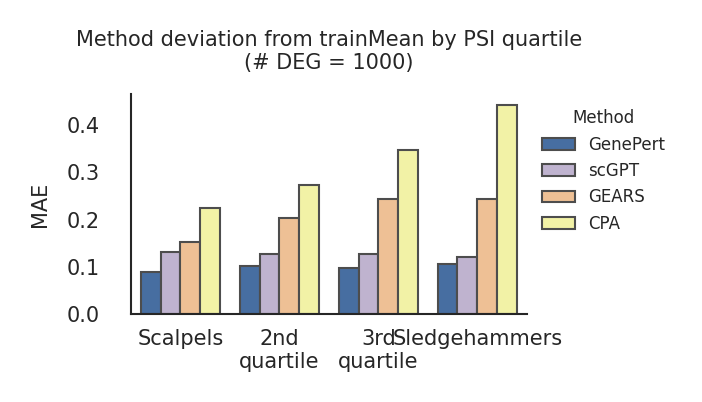

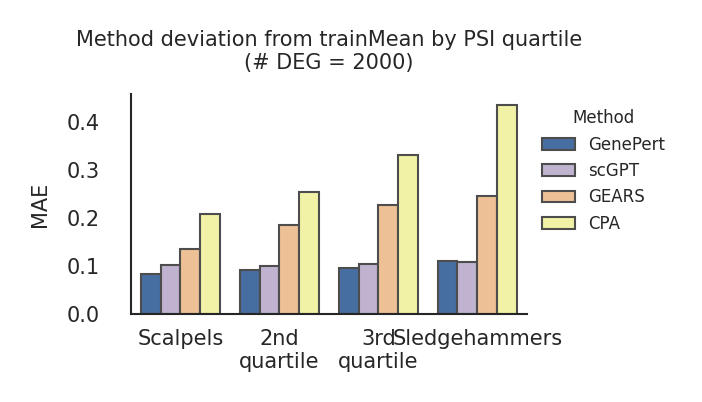

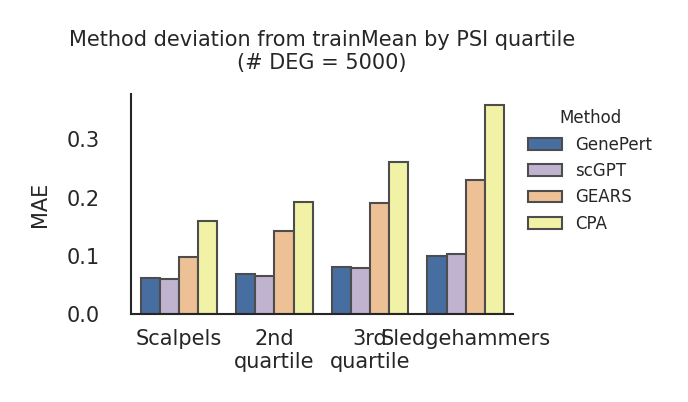

In [44]:
# =========================================================
# Spearman: MAE of each method vs trainMean, per PSI quartile
# =========================================================
other_methods = [m for m in METHOD_ORDER if m not in ('trainMean', 'scouter')]

diff_records = []
for deg in [1000, 2000, 5000]:
    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'spearman_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]

        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')

        for m in other_methods:
            if m in pivot.columns and 'trainMean' in pivot.columns:
                valid = pivot[['trainMean', m]].dropna()
                if len(valid) >= 1:
                    mae = np.mean(np.abs(valid[m].values - valid['trainMean'].values))
                else:
                    mae = np.nan
                diff_records.append({
                    'DEG': deg, 'quarter': qname, 'method': m, 'MAE': mae
                })

diff_df = pd.DataFrame(diff_records)
bar_remap = dict(zip(quarter_names, quarter_names_bar))
diff_df['quarter'] = diff_df['quarter'].map(bar_remap)

sns.set_theme(style="white")
for deg in [1000, 2000, 5000]:
    df_deg = diff_df[diff_df.DEG == deg]

    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    sns.barplot(data=df_deg, x='quarter', y='MAE', hue='method',
                hue_order=other_methods,
                palette={m: PALETTE[m] for m in other_methods},
                edgecolor='0.3', linewidth=0.5, ax=ax,
                order=quarter_names_bar, errorbar=None)
    ax.set_xlabel('')
    ax.set_ylabel('MAE', fontsize=5)
    ax.set_title(f'Method deviation from trainMean by PSI quartile\n(# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5, length=0)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, title='Method', title_fontsize=4,
              bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)

    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_spearman_mae_vs_trainMean_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_spearman_mae_vs_trainMean_DEG{deg}.svg', bbox_inches='tight', dpi=300)
    plt.show()

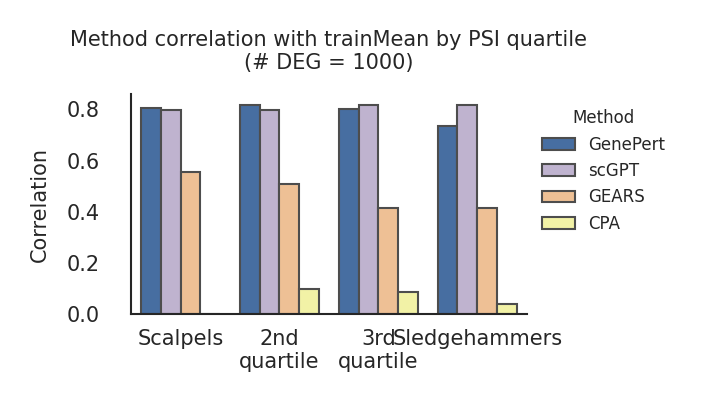

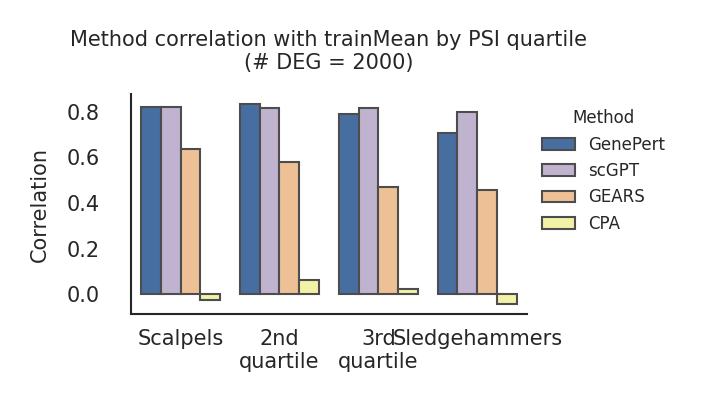

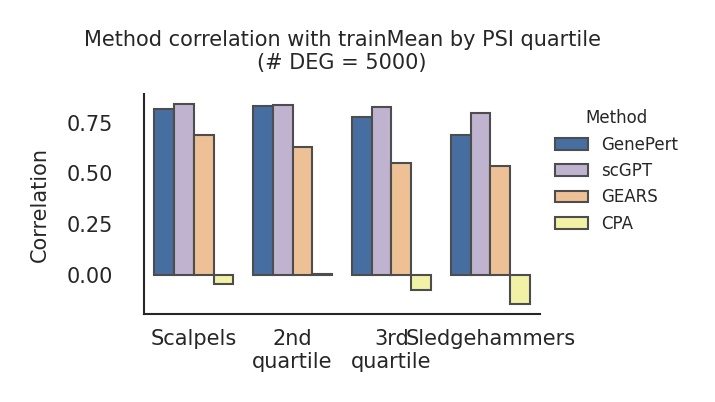

In [45]:
# =========================================================
# Spearman: correlation of per-perturbation performance with trainMean
# =========================================================
from scipy.stats import spearmanr

corr_methods = [m for m in METHOD_ORDER if m not in ('trainMean', 'scouter')]

corr_records = []
for deg in [1000, 2000, 5000]:
    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'spearman_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]

        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')

        for m in corr_methods:
            if m in pivot.columns and 'trainMean' in pivot.columns:
                for ds in pivot.index.get_level_values('DataSet').unique():
                    ds_data = pivot.loc[ds, ['trainMean', m]].dropna()
                    if len(ds_data) >= 3:
                        rho, _ = spearmanr(ds_data['trainMean'], ds_data[m])
                    else:
                        rho = np.nan
                    corr_records.append({
                        'DEG': deg, 'quarter': qname, 'method': m,
                        'rho': rho, 'DataSet': ds
                    })

corr_df = pd.DataFrame(corr_records)
bar_remap = dict(zip(quarter_names, quarter_names_bar))
corr_df['quarter'] = corr_df['quarter'].map(bar_remap)

sns.set_theme(style="white")
for deg in [1000, 2000, 5000]:
    df_deg = corr_df[corr_df.DEG == deg]

    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    sns.barplot(data=df_deg, x='quarter', y='rho', hue='method',
                hue_order=corr_methods,
                palette={m: PALETTE[m] for m in corr_methods},
                edgecolor='0.3', linewidth=0.5, ax=ax,
                order=quarter_names_bar, errorbar=None)
    ax.set_xlabel('')
    ax.set_ylabel('Correlation', fontsize=5)
    ax.set_title(f'Method correlation with trainMean by PSI quartile\n(# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5, length=0)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, title='Method', title_fontsize=4,
              bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)

    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_spearman_corr_vs_trainMean_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_spearman_corr_vs_trainMean_DEG{deg}.svg', bbox_inches='tight', dpi=300)
    plt.show()

In [46]:
corr_df.pivot_table(index='quarter', columns='method', values='rho', aggfunc='mean')


method,CPA,GEARS,GenePert,scGPT
quarter,,,,
2nd\nquartile,0.055463,0.573354,0.827437,0.817299
3rd\nquartile,0.012160,0.478311,0.789494,0.821262
Scalpels,-0.022298,0.628279,0.814160,0.819696
Sledgehammers,-0.049419,0.469666,0.709418,0.805825


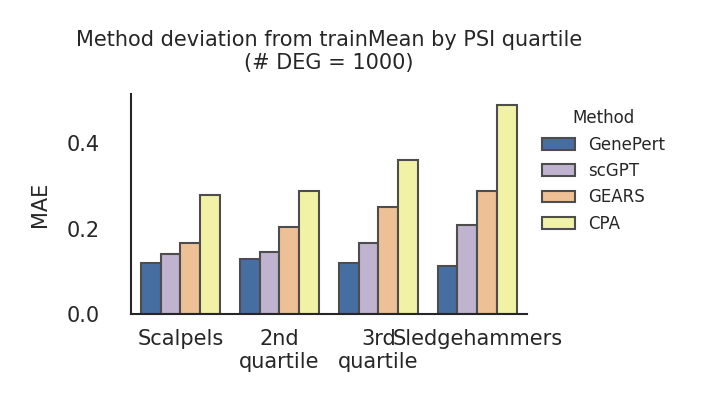

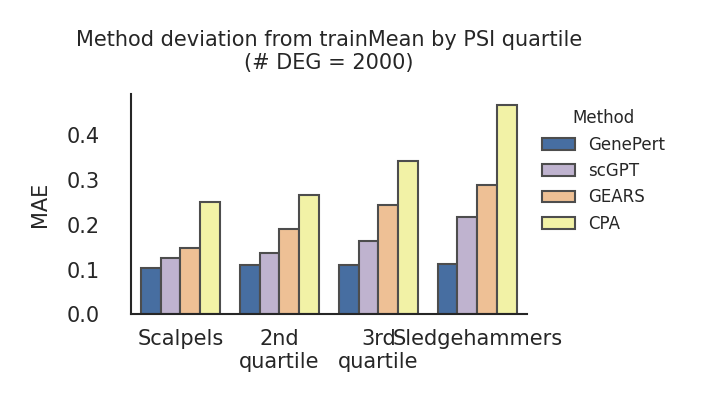

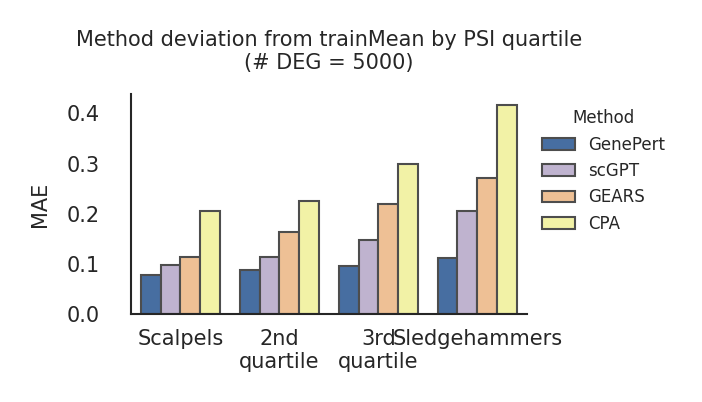

In [47]:
# =========================================================
# Pearson: MAE of each method vs trainMean, per PSI quartile
# =========================================================
other_methods = [m for m in METHOD_ORDER if m not in ('trainMean', 'scouter')]

diff_records_p = []
for deg in [1000, 2000, 5000]:
    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'pearson_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]

        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')

        for m in other_methods:
            if m in pivot.columns and 'trainMean' in pivot.columns:
                valid = pivot[['trainMean', m]].dropna()
                if len(valid) >= 1:
                    mae = np.mean(np.abs(valid[m].values - valid['trainMean'].values))
                else:
                    mae = np.nan
                diff_records_p.append({
                    'DEG': deg, 'quarter': qname, 'method': m, 'MAE': mae
                })

diff_df_p = pd.DataFrame(diff_records_p)
bar_remap = dict(zip(quarter_names, quarter_names_bar))
diff_df_p['quarter'] = diff_df_p['quarter'].map(bar_remap)

sns.set_theme(style="white")
for deg in [1000, 2000, 5000]:
    df_deg = diff_df_p[diff_df_p.DEG == deg]

    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    sns.barplot(data=df_deg, x='quarter', y='MAE', hue='method',
                hue_order=other_methods,
                palette={m: PALETTE[m] for m in other_methods},
                edgecolor='0.3', linewidth=0.5, ax=ax,
                order=quarter_names_bar, errorbar=None)
    ax.set_xlabel('')
    ax.set_ylabel('MAE', fontsize=5)
    ax.set_title(f'Method deviation from trainMean by PSI quartile\n(# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5, length=0)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, title='Method', title_fontsize=4,
              bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)

    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_pearson_mae_vs_trainMean_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_pearson_mae_vs_trainMean_DEG{deg}.svg', bbox_inches='tight', dpi=300)
    plt.show()

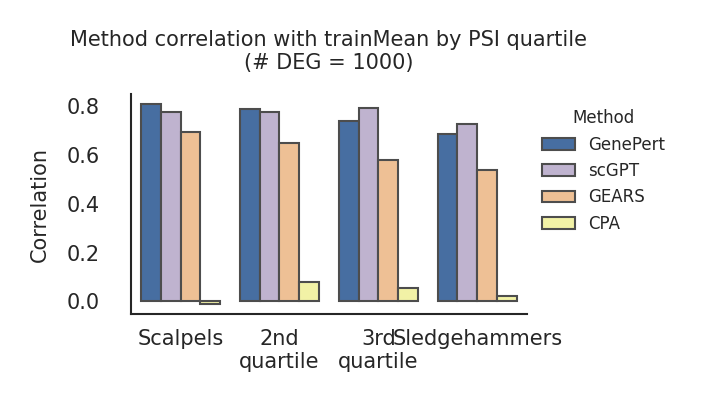

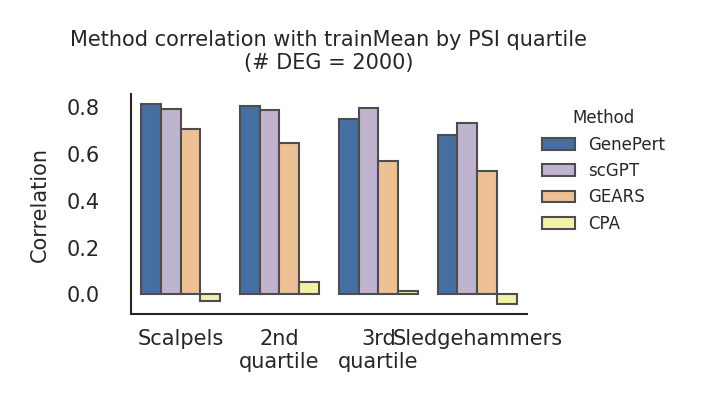

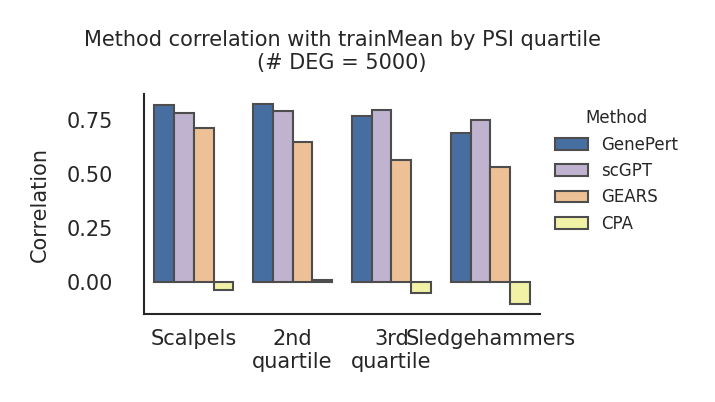

In [48]:
# =========================================================
# Pearson: correlation of per-perturbation performance with trainMean
# =========================================================
from scipy.stats import spearmanr

corr_methods = [m for m in METHOD_ORDER if m not in ('trainMean', 'scouter')]

corr_records_p = []
for deg in [1000, 2000, 5000]:
    for qname, qlist in zip(quarter_names, quarter_lists):
        sub = new_metrics[
            (new_metrics.metric == 'pearson_distance_delta')
            & (new_metrics.DEG == deg)
            & (new_metrics.perturb.isin(qlist))
        ].copy()

        all_ds = sub['DataSet'].unique()
        pcounts = sub.groupby('perturb')['DataSet'].nunique()
        shared = pcounts[pcounts == len(all_ds)].index
        sub = sub[sub['perturb'].isin(shared)]

        agg = sub.groupby(['DataSet', 'perturb', 'method'])['performance'].median().reset_index()
        pivot = agg.pivot_table(index=['DataSet', 'perturb'], columns='method', values='performance')

        for m in corr_methods:
            if m in pivot.columns and 'trainMean' in pivot.columns:
                for ds in pivot.index.get_level_values('DataSet').unique():
                    ds_data = pivot.loc[ds, ['trainMean', m]].dropna()
                    if len(ds_data) >= 3:
                        rho, _ = spearmanr(ds_data['trainMean'], ds_data[m])
                    else:
                        rho = np.nan
                    corr_records_p.append({
                        'DEG': deg, 'quarter': qname, 'method': m,
                        'rho': rho, 'DataSet': ds
                    })

corr_df_p = pd.DataFrame(corr_records_p)
bar_remap = dict(zip(quarter_names, quarter_names_bar))
corr_df_p['quarter'] = corr_df_p['quarter'].map(bar_remap)

sns.set_theme(style="white")
for deg in [1000, 2000, 5000]:
    df_deg = corr_df_p[corr_df_p.DEG == deg]

    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    sns.barplot(data=df_deg, x='quarter', y='rho', hue='method',
                hue_order=corr_methods,
                palette={m: PALETTE[m] for m in corr_methods},
                edgecolor='0.3', linewidth=0.5, ax=ax,
                order=quarter_names_bar, errorbar=None)
    ax.set_xlabel('')
    ax.set_ylabel('Correlation', fontsize=5)
    ax.set_title(f'Method correlation with trainMean by PSI quartile\n(# DEG = {deg})', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5, length=0)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, title='Method', title_fontsize=4,
              bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)

    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig3/Fig3A_pearson_corr_vs_trainMean_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig3/Fig3A_pearson_corr_vs_trainMean_DEG{deg}.svg', bbox_inches='tight', dpi=300)
    plt.show()